# Classification Basics

## Overview
This notebook presents a comprehensive implementation of **Classification Basics**. It demonstrates the fundamental mechanics and technical approaches used to solve problems within this domain.

## Objectives
- Implement foundational classification algorithms.
- Preprocess data for classification tasks.
- Evaluate model performance using standard accuracy metrics.


## Goals
In this implementation, you will:
- learn how to use polynomials to fit more complex models using linear regression.

<a name="toc_40291_2"></a>
# Problem Statement
As we saw in the previous lab, [linear regression](https://www.ibm.com/topics/linear-regression) analysis is used to predict the value of a variable (*y*) based on the value of another variable (*x*). The variable you want to predict is called the dependent variable (*y*). The variable you are using to predict the other variable's value is called the independent variable (*x*).

This form of analysis estimates the coefficients of a linear equation, involving one or more independent variables that best predict the value of the dependent variable. Linear regression fits a straight line or surface that minimizes the discrepancies between predicted and actual output values.



--

In this project we are going to see how this algorithm works with a simple example, using the Python library "numpy", especifically the ["polyfit"](https://numpy.org/doc/stable/reference/generated/numpy.polyfit.html) and the ["poly1d"](https://numpy.org/doc/stable/reference/generated/numpy.poly1d.html) functions.

First, we are going to import some libraries and functions that we will use:

*   **Numpy**, that allows us to work with arrays and create the models
*   The **"pyplot"** package from Matplotlib, that will allow us to plot some results

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Then we define some functions that will be useful to plot the results of the models we will create

In [2]:
# Plot a figure with the data and the regression function
def plot_data(xTrain, yTrain, model, name, xVal = None, yVal = None, validation = False):
  polyline = np.linspace(1.9, 13, 100)

  fig, ax = plt.subplots(figsize=(10, 7))
  plt.scatter(xTrain, yTrain, s=100, c = 'b')
  if validation:
    plt.scatter(xVal, yVal, s=100, c = 'orange')
  plt.rcParams.update({'font.size': 14})

  ax.set_xlabel('years(x)')
  ax.set_ylabel('price(y)')
  ax.set_title('price for used cars '+ name)

  ax.axis([1.5, 13, 0, 12000])
  ax.grid(True);
  plt.plot(polyline, model(polyline))


## DATA

In this case, we are presented with a simple problem: the price of used cars along the years. Cars are then presumed to be in a linear relationship with how old it is. We have two datasets:

*   Training data, where **xTrain** contains a single feature (car age) for the training dataset, and **yTrain** contains the ground truth labels of these samples, in this case the price of the car. This dataset will be used to fit the models we will train.
*   Validation data, where **xVal** contains the features of the validation dataset, so, the age of each car, and **yVal** contains the ground truth of these samples, in this case the price of the car. This dataset will be used to verify how accurate the fitted models are, using data that has not been used to train the model.

In [3]:
# Training data
xTrain = np.array([2, 2.5, 2.75, 3, 3.5, 4, 4.5, 5, 5.5, 6, 7, 8, 9, 9.5, 10, 11, 12, 12.5])
# Labels of the training data
yTrain = np.array([11200, 9950, 10750, 9400, 7500, 6300, 5800, 5700, 4200, 4400, 4200, 3800, 3950, 2700, 2100, 2500, 1850, 1800])

# Validation data
xVal = np.array([2.5, 2.75, 3.5, 4, 5, 5.75, 6.5, 7, 8, 8.5, 9, 10.5, 12, 9.5])
# Labels of the validation data
yVal = np.array([10250, 8750, 8500, 5800, 6200, 5000, 4500, 3500, 3250, 3000, 2250, 2500, 2250, 3800])

First, we are going to plot the training data and analize it.

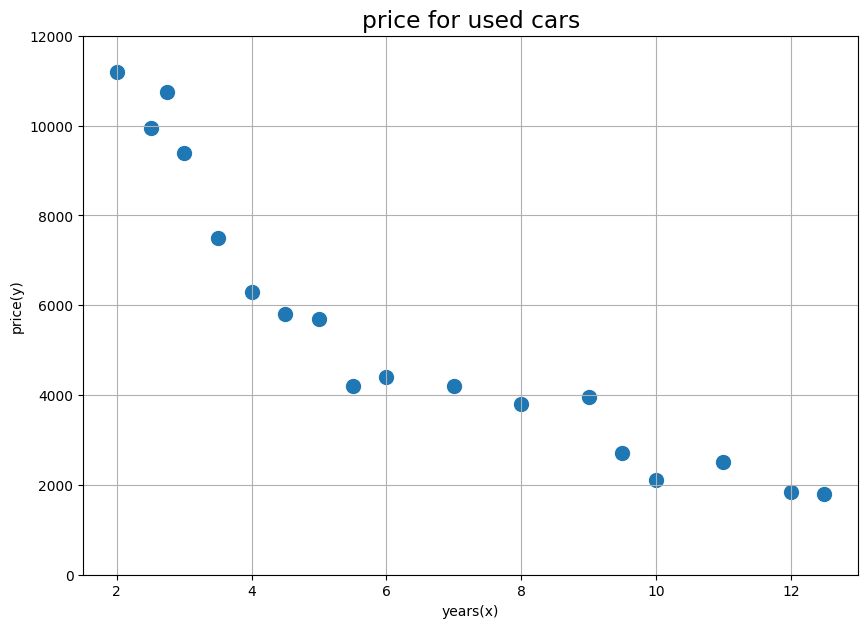

In [4]:
# Plot the training data
fig, ax = plt.subplots(figsize=(10, 7))
plt.scatter(xTrain, yTrain, s=100)

plt.rcParams.update({'font.size': 14})

ax.set_xlabel('years(x)')
ax.set_ylabel('price(y)')
ax.set_title('price for used cars')

ax.axis([1.5, 13, 0, 12000])
ax.grid(True)

<a name="toc_40291_2.2"></a>
##  Modeling Linear Regressions
To start, we have an example of how to create a basic regressions function with dregree = 1 using the ["polyfit"](https://numpy.org/doc/stable/reference/generated/numpy.polyfit.html) and the ["poly1d"](https://numpy.org/doc/stable/reference/generated/numpy.poly1d.html) functions. Next, the mean error percentage is computed for the train data and the fitted function and the training data is plotted.

Mean error train:
24.58


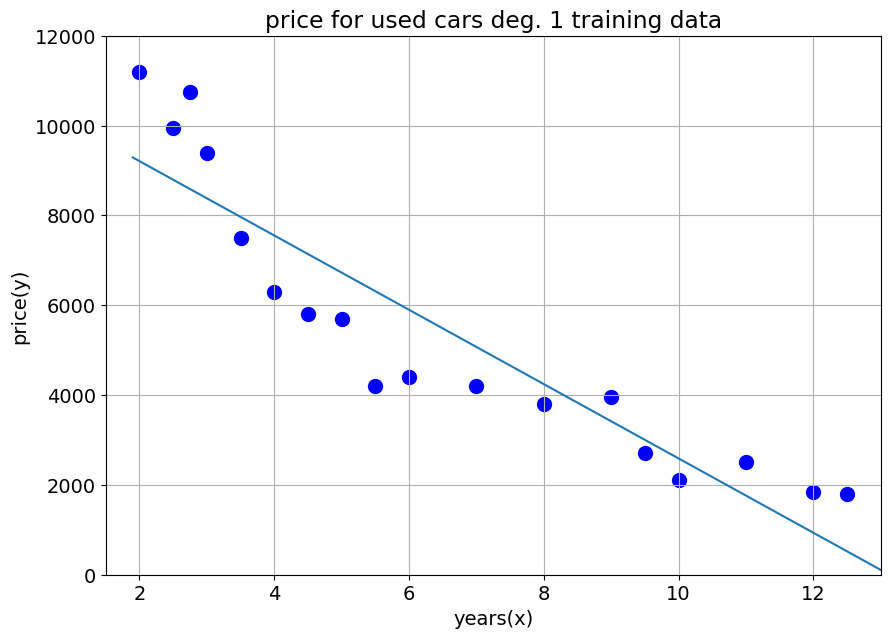

In [5]:
#polynomial fit with degree = 1
modeld1 = np.poly1d(np.polyfit(xTrain, yTrain, 1))
#mean error percentatge is computed for the train data
print("Mean error train:")
per1 = np.sum(np.abs(modeld1(xTrain)-yTrain)/yTrain)/len(yTrain)*100
print(round(per1,2))
# plot model and training data
plot_data(xTrain, yTrain, modeld1, "deg. 1 training data")

Sometimes a higher degree function give better results to our problems.

Define a new model with a polynomial function of degrees 2 and 4, and compare the results with the linear ones. **Which one is better?**

Mean error train deg. 2:
14.21
Mean error train deg. 4:
8.81


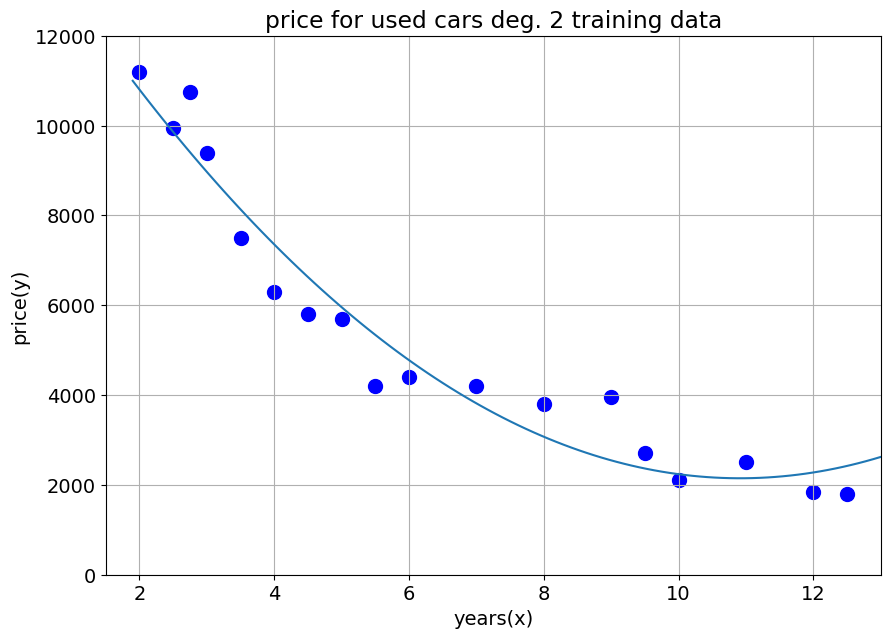

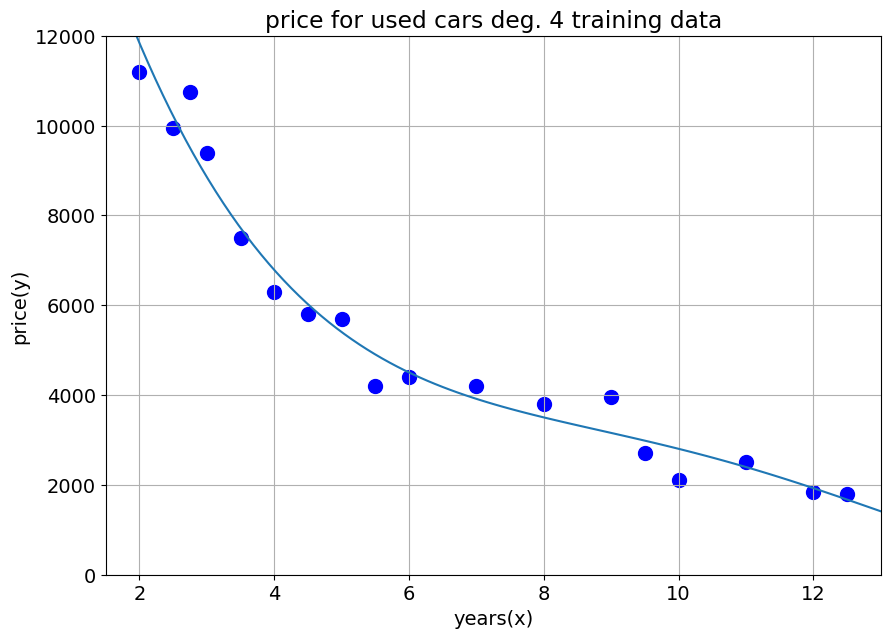

In [8]:


#polynomial fit with degree = 2
modeld2 = np.poly1d(np.polyfit(xTrain, yTrain, 2))
#mean error percentatge is computed for the train data
print("Mean error train deg. 2:")
per2 = np.sum(np.abs(modeld2(xTrain)-yTrain)/yTrain)/len(yTrain)*100
print(round(per2,2))
# plot model and training data
plot_data(xTrain, yTrain, modeld2, "deg. 2 training data")

#polynomial fit with degree = 4
modeld4 = np.poly1d(np.polyfit(xTrain, yTrain, 4))
#mean error percentatge is computed for the train data
print("Mean error train deg. 4:")
per4 = np.sum(np.abs(modeld4(xTrain)-yTrain)/yTrain)/len(yTrain)*100
print(round(per4,2))
# plot model and training data
plot_data(xTrain, yTrain, modeld4, "deg. 4 training data")

As we saw before, we have another dataset called "validation data" that allows us to further check which model is better for us. Compute the mean error percentage for the model with the validation data and compare them with the training data . **Now, which model do you think is better for our data? Is it the same as the one chosen before? Explain why.**

**The model with 1 degree polynomial , both training and validation errors are high.**

**The degree 4 polynomial model fits the training data better, but its validation error starts to increase, which shows that it is starting to overfit.**

**The  model with 2 degree polynomial  gives the both  lowest validation error and training error  , which means it performs well and seems to be better model .**

Mean error train model deg 1:
24.58
Mean error test model deg 1:
25.17
Mean error train model deg 2:
14.21
Mean error test model deg 2:
9.98
Mean error train model deg 4:
8.81
Mean error test model deg 4:
12.3


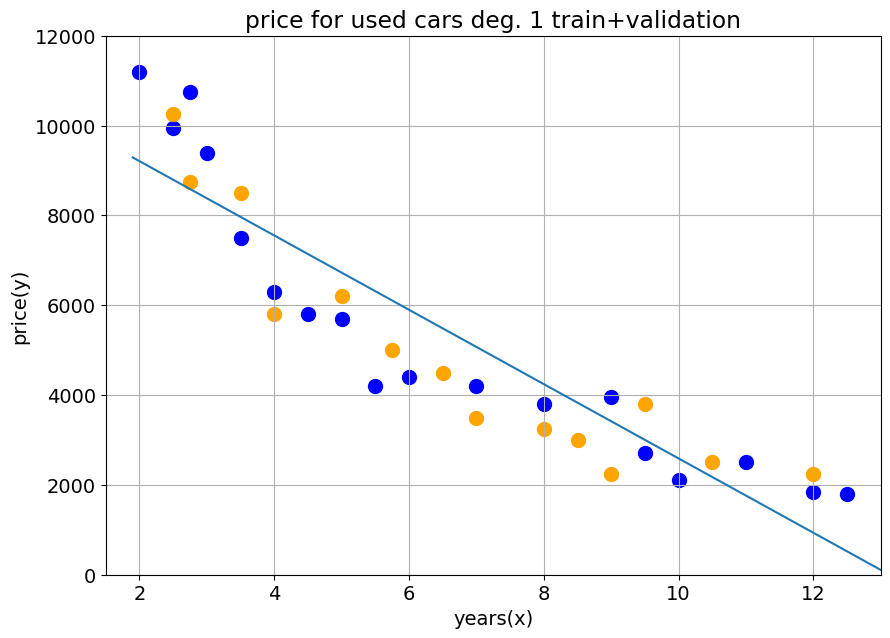

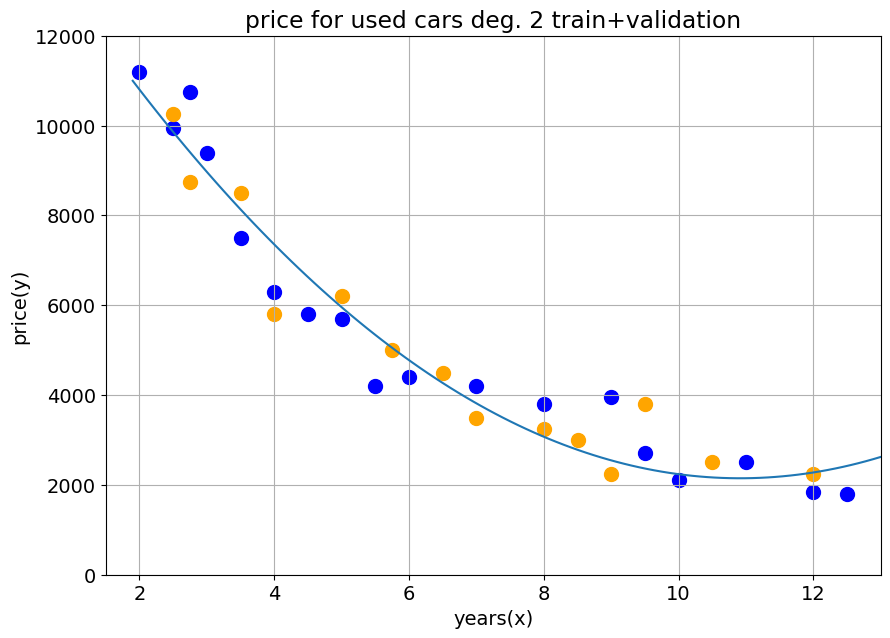

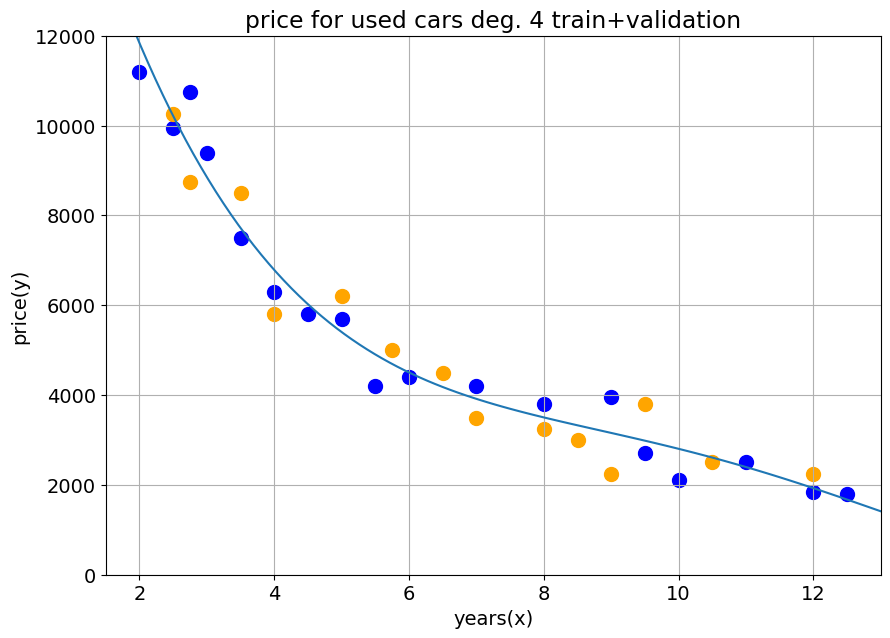

In [27]:
#mean error percentatge for model deg. 1 is computed for the train and validation data
print("Mean error train model deg 1:")
print(round(per1,2))
per1_valid = np.sum(np.abs(modeld1(xVal)-yVal)/yVal)/len(yVal)*100

print("Mean error test model deg 1:")
print(round(per1_valid,2))

# plot model and training data
plot_data(xTrain, yTrain, modeld1, "deg. 1 train+validation", xVal, yVal, True)





#mean error percentatge for model deg. 1 is computed for the train and validation data
print("Mean error train model deg 2:")
print(round(per2,2))
per2_valid = np.sum(np.abs(modeld2(xVal)-yVal)/yVal)/len(yVal)*100

print("Mean error test model deg 2:")
print(round(per2_valid,2))

# plot model and training data
plot_data(xTrain, yTrain, modeld2, "deg. 2 train+validation", xVal, yVal, True)

#mean error percentatge for model deg. 1 is computed for the train and validation data
print("Mean error train model deg 4:")
print(round(per4,2))
per4_valid = np.sum(np.abs(modeld4(xVal)-yVal)/yVal)/len(yVal)*100

print("Mean error test model deg 4:")
print(round(per4_valid,2))

# plot model and training data
plot_data(xTrain, yTrain, modeld4, "deg. 4 train+validation", xVal, yVal, True)

In reality, when running Gradient Descent, your loss is computed as the Mean Squared Error.
1. Import the function "mean_squared_error" from the library "sklearn.metrics"
2. Create a FOR loop that trains models from degree 1 to degree 14
3. Plot the model at every iteration, and compute de MSE for train and for validation. Store them in two vectors "TrainMSE" and "ValMSE".


In [25]:
from sklearn.metrics import mean_squared_error

TrainMSE, ValMSE = [], []

deg = range(1, 15)

for d in deg:
    model = np.poly1d(np.polyfit(xTrain, yTrain, d))
    y_train_pred = model(xTrain)
    y_val_pred = model(xVal)


    train_mse = mean_squared_error(yTrain, y_train_pred)
    val_mse = mean_squared_error(yVal, y_val_pred)


    TrainMSE.append(train_mse)
    ValMSE.append(val_mse)


    print(f"Degree {d}: Train MSE = {train_mse:.2f}, Validation MSE = {val_mse:.2f}")


    #plot_data(xTrain, yTrain, model, f"degree {d}", xVal, yVal, True)


print("\nAll Train MSE values:", [round(v, 2) for v in TrainMSE])
print("All Validation MSE values:", [round(v, 2) for v in ValMSE])

Degree 1: Train MSE = 1497428.85, Validation MSE = 1139035.18
Degree 2: Train MSE = 518522.31, Validation MSE = 406056.43
Degree 3: Train MSE = 266259.02, Validation MSE = 350732.47
Degree 4: Train MSE = 259139.95, Validation MSE = 351929.99
Degree 5: Train MSE = 204363.56, Validation MSE = 490565.58
Degree 6: Train MSE = 155890.85, Validation MSE = 559819.69
Degree 7: Train MSE = 155740.17, Validation MSE = 555035.83
Degree 8: Train MSE = 155028.38, Validation MSE = 551504.13
Degree 9: Train MSE = 144365.93, Validation MSE = 623854.37
Degree 10: Train MSE = 103349.16, Validation MSE = 686784.55
Degree 11: Train MSE = 99196.83, Validation MSE = 683898.15
Degree 12: Train MSE = 50188.22, Validation MSE = 794175.48
Degree 13: Train MSE = 35298.72, Validation MSE = 859041.16
Degree 14: Train MSE = 30678.25, Validation MSE = 911188.81

All Train MSE values: [1497428.85, 518522.31, 266259.02, 259139.95, 204363.56, 155890.85, 155740.17, 155028.38, 144365.93, 103349.16, 99196.83, 50188.22, 35

Plot "TrainMSE" and "ValMSE" for every degree of polynomial. **What would be the best model? Explain why**

**From the Validation Mean Squared Error list, the minimum validation error occurs at degree 3 (≈ 350,732.47.)**

**Train MSE decreases as degree increases (models fit training data better), but ValMSE drops until degree 3 and then rises, showing overfitting beyond degree 3..**

**Therefore, degree 3 balances fit and generalization best.**

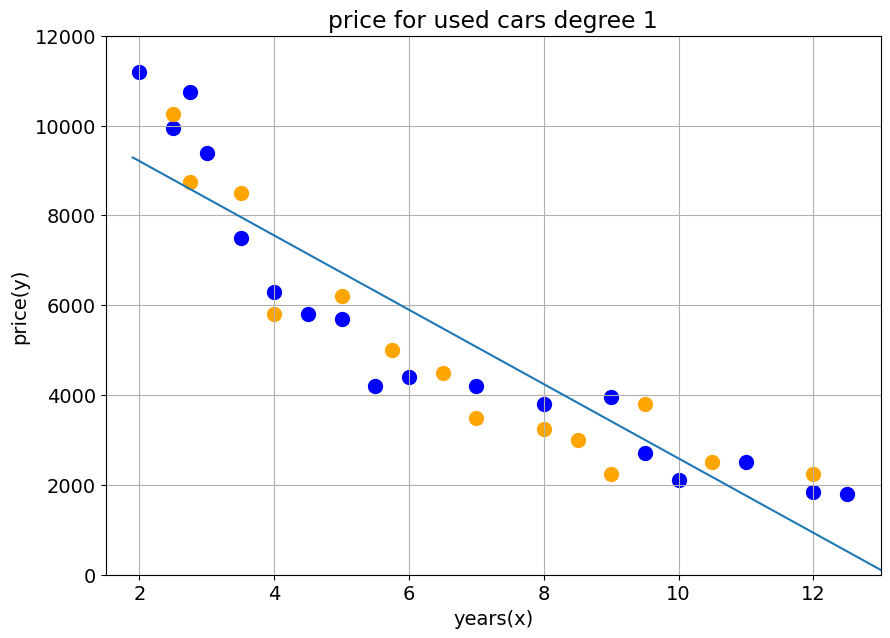

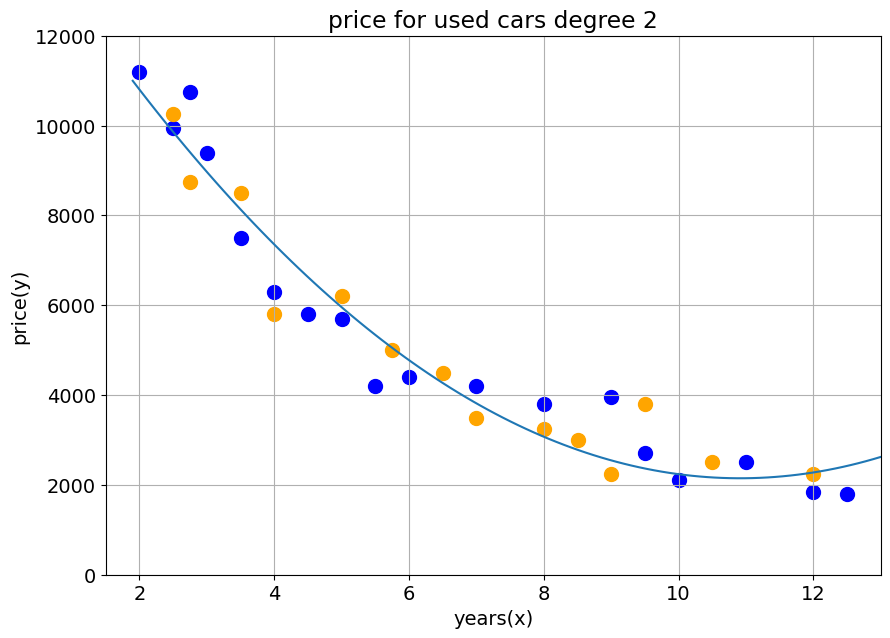

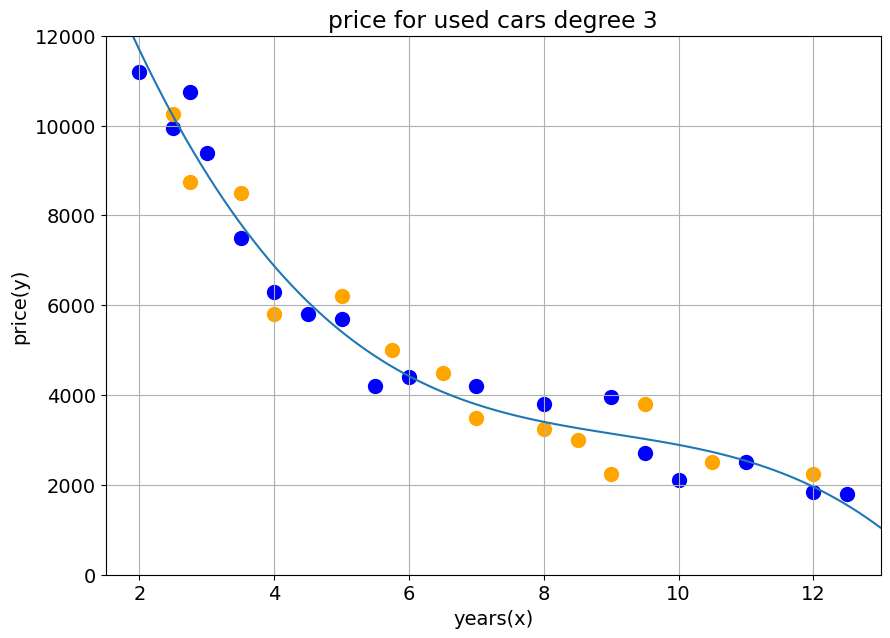

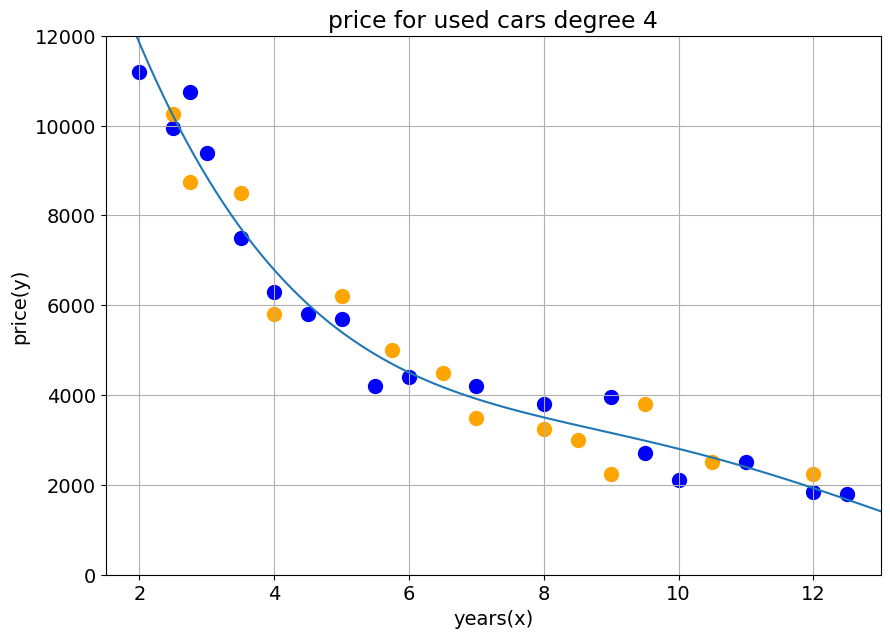

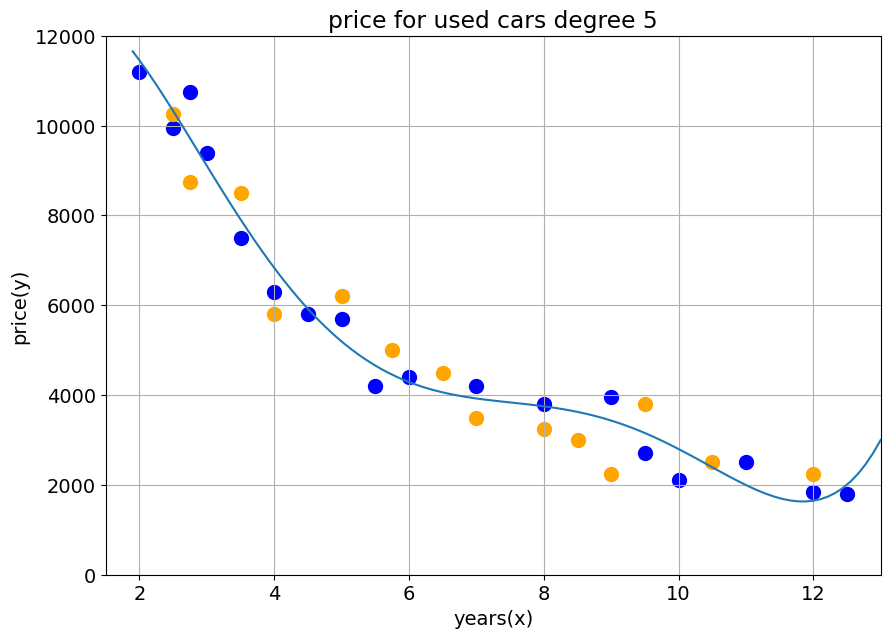

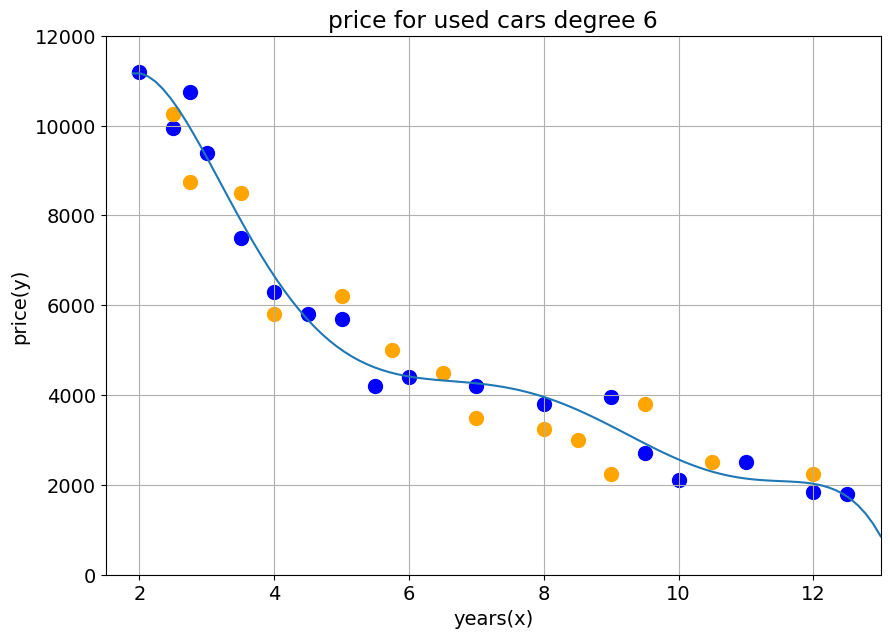

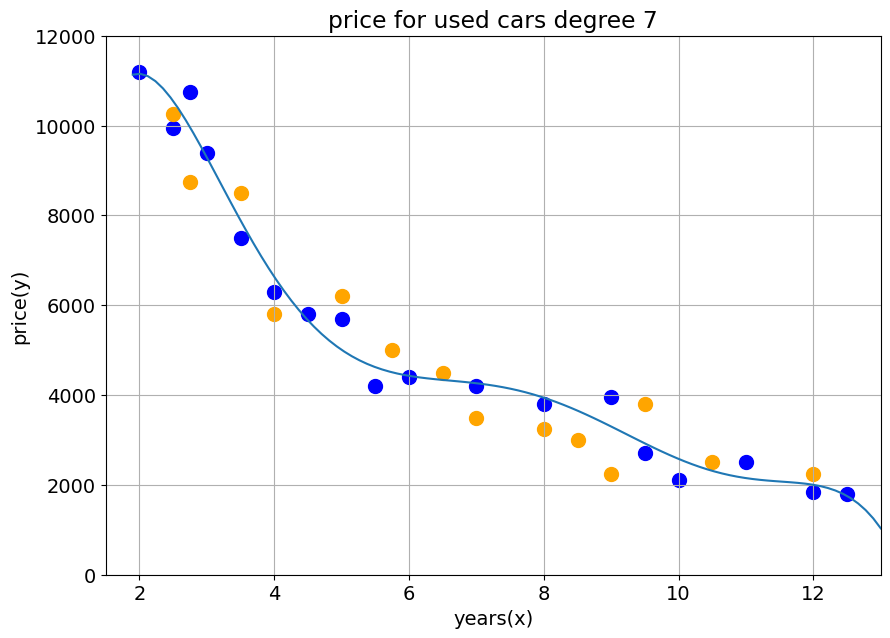

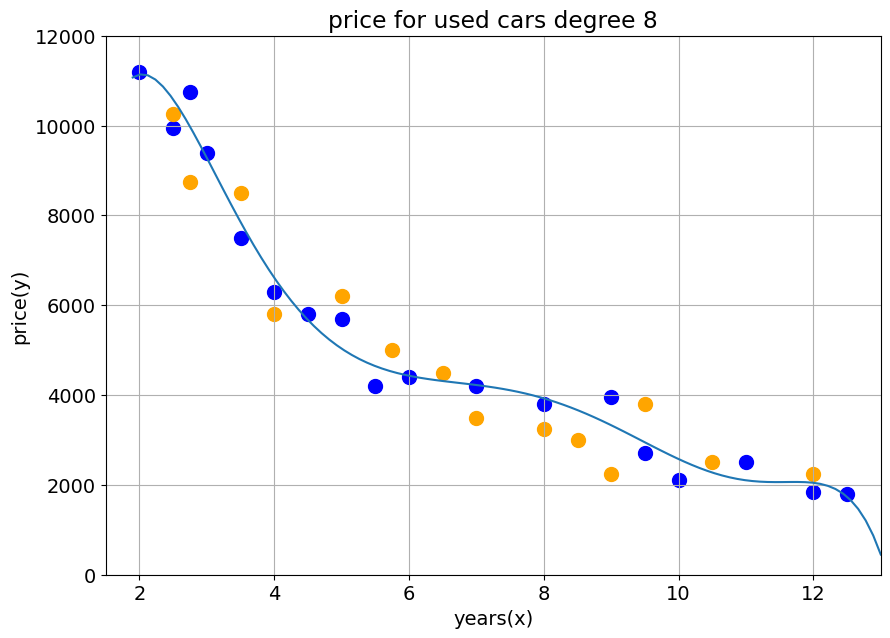

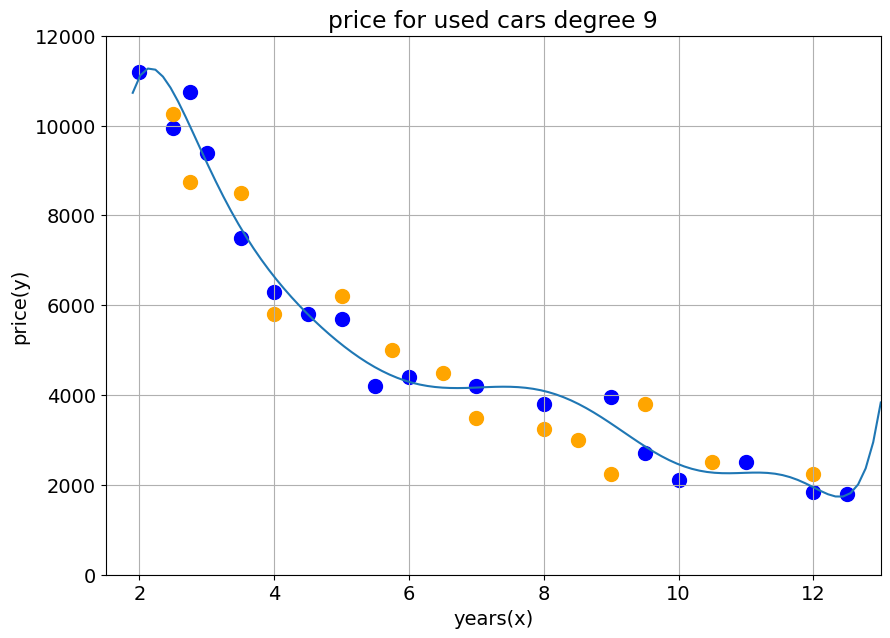

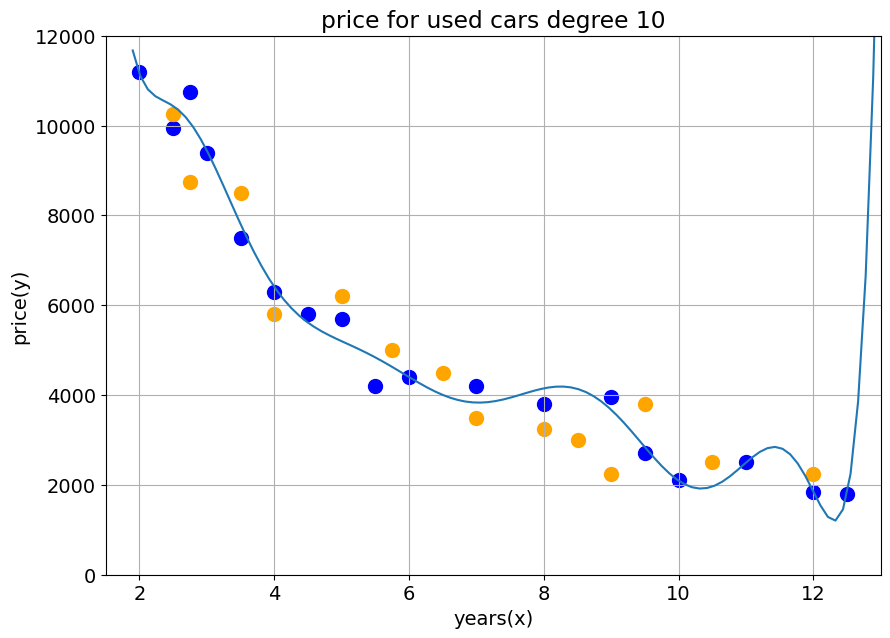

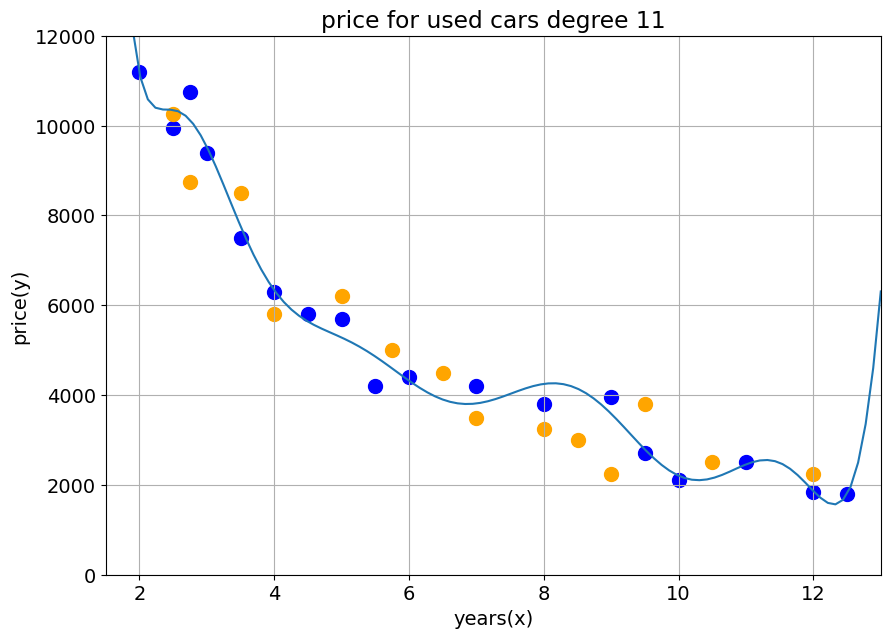

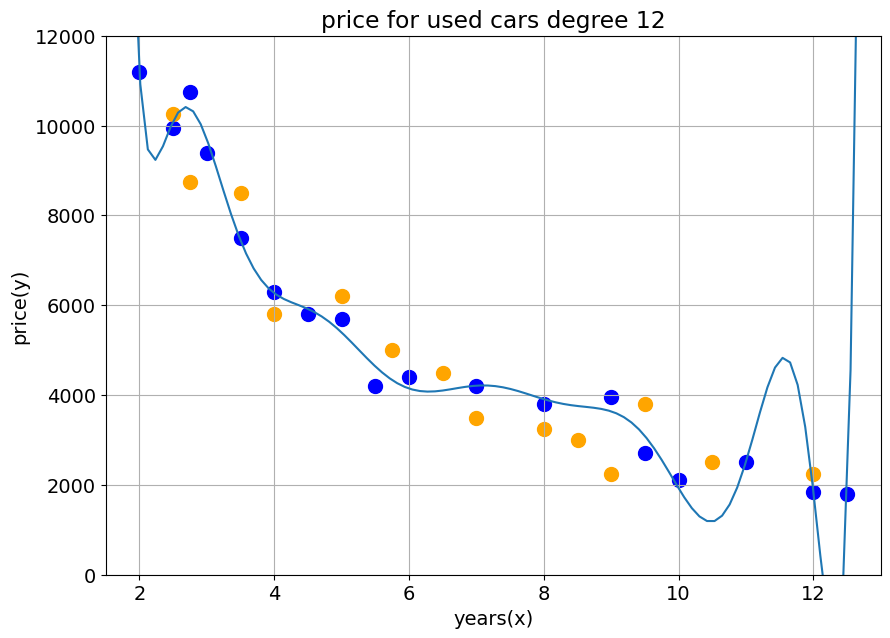

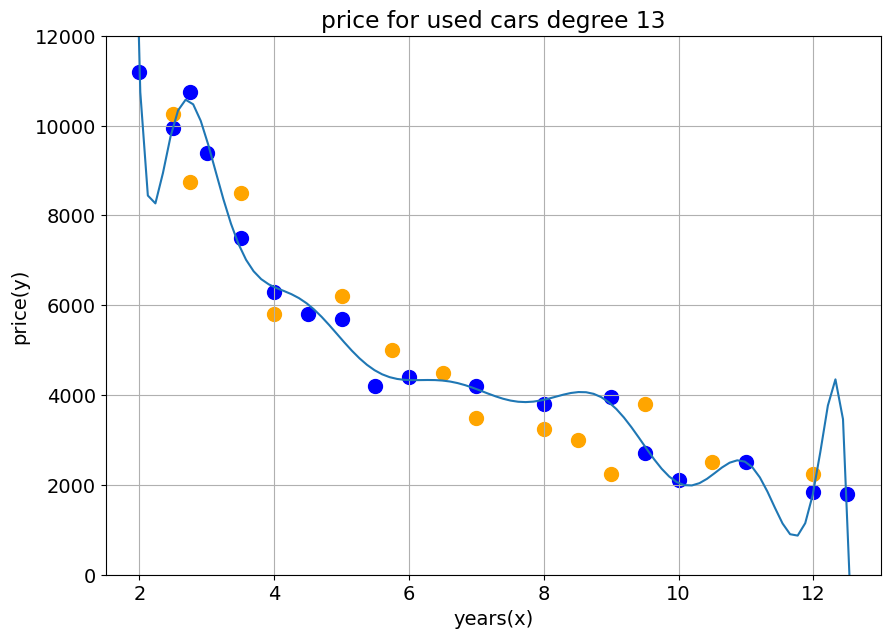

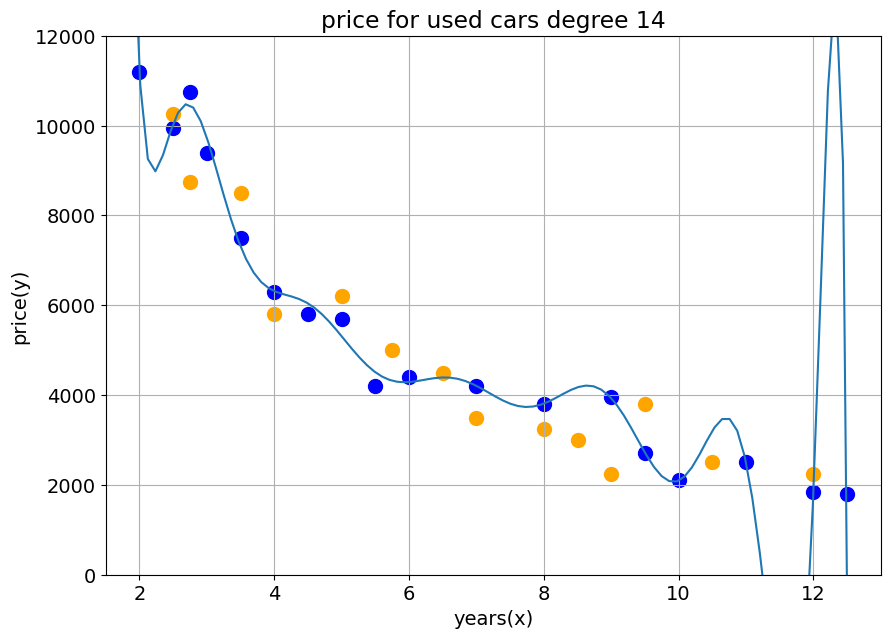

In [26]:
for d in deg:
    model = np.poly1d(np.polyfit(xTrain, yTrain, d))
    y_train_pred = model(xTrain)
    y_val_pred = model(xVal)


    train_mse = mean_squared_error(yTrain, y_train_pred)
    val_mse = mean_squared_error(yVal, y_val_pred)


    TrainMSE.append(train_mse)
    ValMSE.append(val_mse)


    plot_data(xTrain, yTrain, model, f"degree {d}", xVal, yVal, True)